In [124]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [125]:
df = pd.read_csv('ds.csv')

In [126]:
len(df)

2111

In [127]:
categoric_var=[]
numeric_var=[]
for i in df.columns:


    x = df[i].value_counts().count()

    if x < 10:
      categoric_var.append(i)
    else:
      numeric_var.append(i)


print(numeric_var)
print(categoric_var)

['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking', 'NObeyesdad']


'not normally distrbuted'

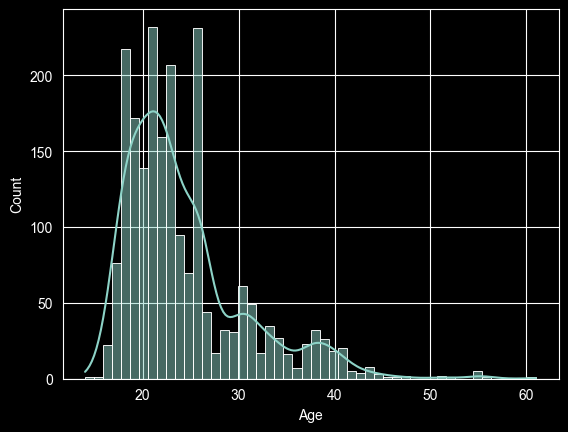

In [144]:
sns.histplot(data= df , x=  df['Age'],kde=True)
"""not normally distrbuted"""

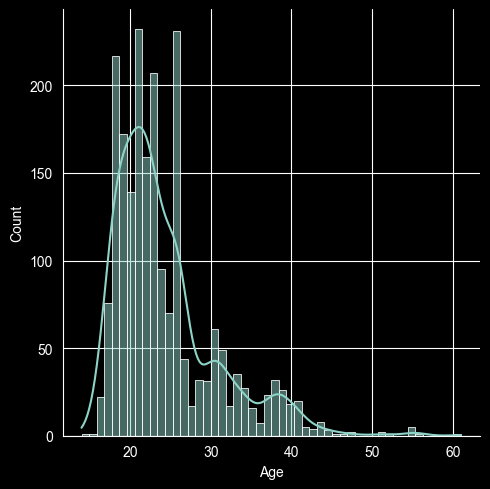

In [129]:
sns.displot(data=  df , x = 'Age',kde=True)

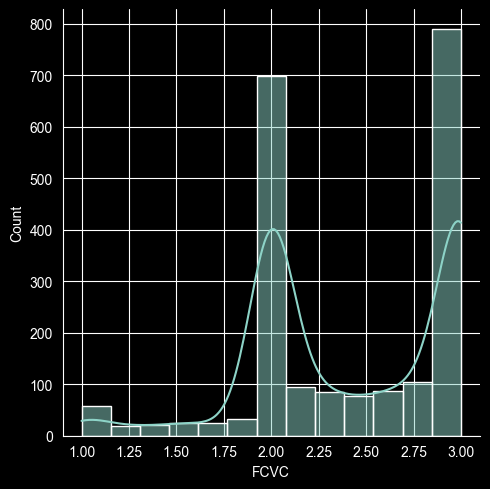

In [146]:
sns.displot(data=df,x = df['FCVC'],kde = True)

In [130]:
df['family_history_with_overweight'].value_counts()

family_history_with_overweight
1    1726
0     385
Name: count, dtype: int64

In [131]:
obs_vals = list(df['family_history_with_overweight'].value_counts().index)
total_obs_vals = list(df['family_history_with_overweight'].value_counts())

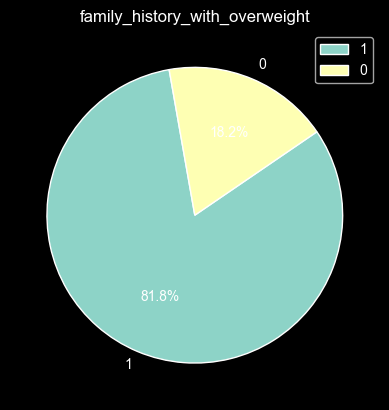

In [132]:
plt.pie(
    total_obs_vals,labels = obs_vals
    ,autopct='%1.1f%%',
            startangle=100,
            labeldistance=1.1

)
plt.title('family_history_with_overweight')
plt.legend()
plt.show()

In [133]:
df['CAEC'].value_counts()

CAEC
1    1765
2     242
3      53
0      51
Name: count, dtype: int64

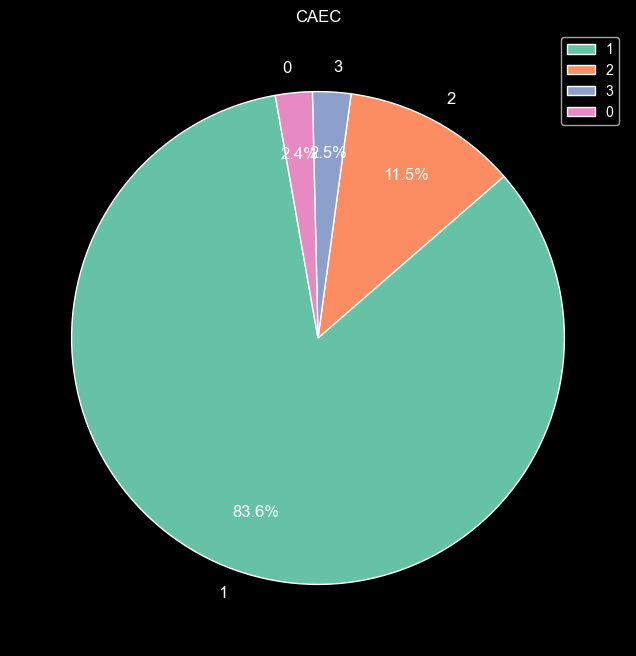

In [134]:
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

plt.figure(figsize=(8,8))

plt.title("CAEC")

obs_vals = list(df['CAEC'].value_counts().index)
total_obs_vals = list(df['CAEC'].value_counts())
plt.pie(
    total_obs_vals, labels=obs_vals
    , autopct='%1.1f%%',
    startangle=100,
    labeldistance=1.1, pctdistance=0.75,
textprops={'fontsize': 12} ,
    colors=colors
)
plt.title('CAEC')
plt.legend()


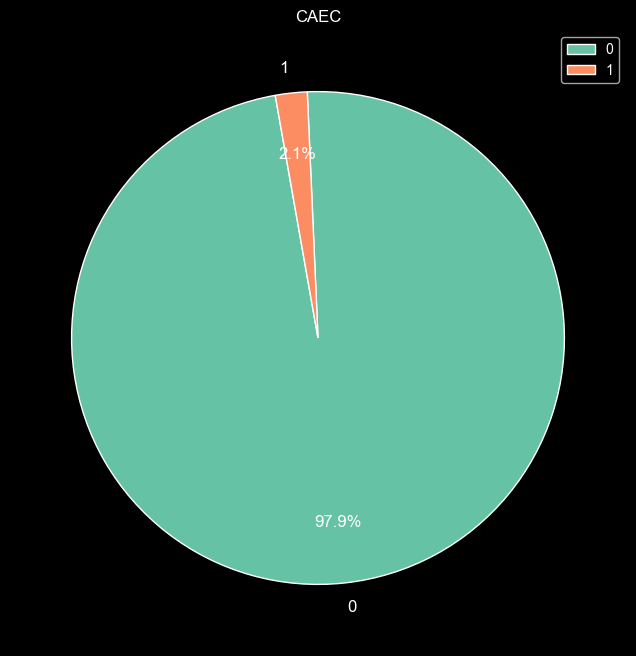

In [135]:
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

plt.figure(figsize=(8,8))

plt.title("Smoking")

obs_vals = list(df['SMOKE'].value_counts().index)
total_obs_vals = list(df['SMOKE'].value_counts())
plt.pie(
    total_obs_vals, labels=obs_vals
    , autopct='%1.1f%%',
    startangle=100,
    labeldistance=1.1, pctdistance=0.75,
textprops={'fontsize': 12} ,
    colors=colors
)
plt.title('CAEC')
plt.legend()


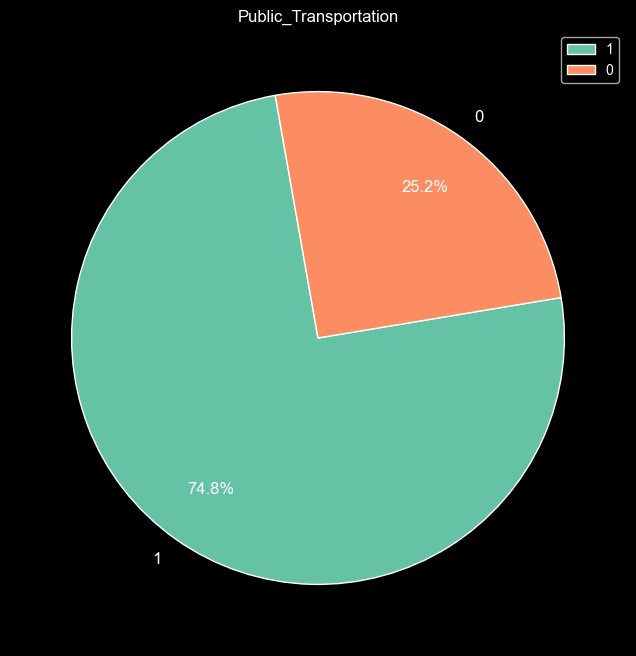

In [136]:
colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

plt.figure(figsize=(8,8))

plt.title("Transportation Usage")

obs_vals = list(df['Public_Transportation'].value_counts().index)
total_obs_vals = list(df['Public_Transportation'].value_counts())
plt.pie(
    total_obs_vals, labels=obs_vals
    , autopct='%1.1f%%',
    startangle=100,
    labeldistance=1.1, pctdistance=0.75,
textprops={'fontsize': 12} ,
    colors=colors
)
plt.title('Public_Transportation')
plt.legend();


In [137]:
df = df.rename(columns={'NObeyesdad':'target'})

In [138]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df[numeric_var])


df_scaled=pd.DataFrame(scaled_data,columns=numeric_var)

<Axes: xlabel='CH2O', ylabel='Density'>

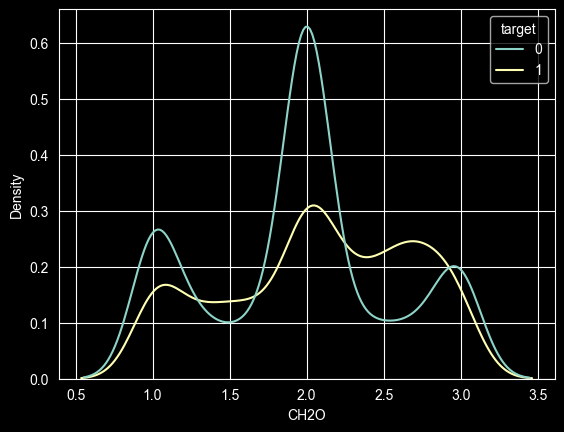

In [139]:
sns.kdeplot(data= df,x= df['CH2O'],hue='target')

<Axes: xlabel='CALC', ylabel='count'>

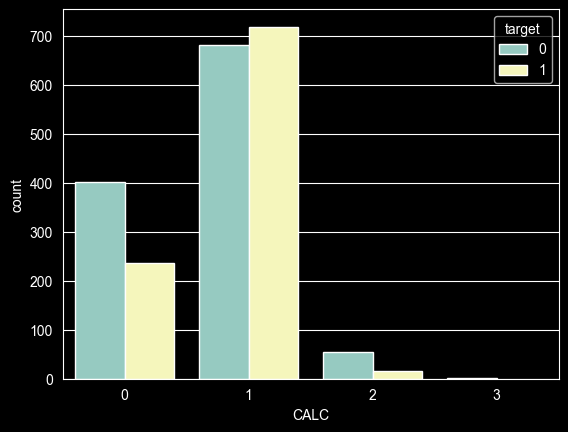

In [140]:
sns.countplot(data=df,x=df['CALC'],hue='target')

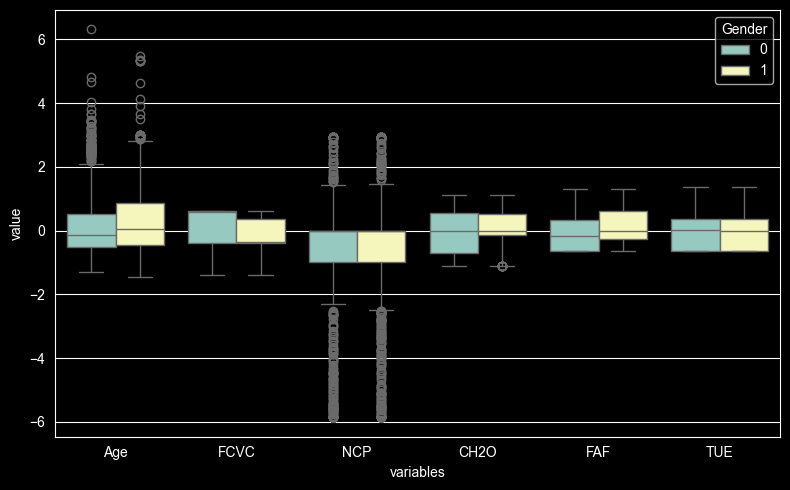

In [141]:
df_new = pd.concat([df_scaled, df.loc[:, "Gender"]], axis = 1)
melted_data = pd.melt(df_new, id_vars = "Gender", var_name = "variables", value_name = "value")
plt.figure(figsize = (8, 5))
sns.boxplot(x = "variables", y = "value", hue = "Gender", data = melted_data)
plt.xlabel("variables")
plt.ylabel("value")
plt.tight_layout()
plt.show();

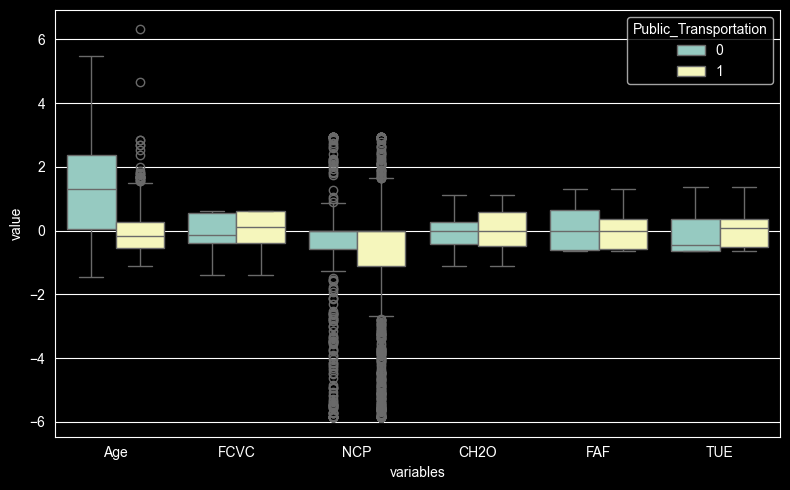

In [142]:
df_new = pd.concat([df_scaled, df.loc[:, "Public_Transportation"]], axis = 1)
melted_data = pd.melt(df_new, id_vars = "Public_Transportation", var_name = "variables", value_name = "value")
plt.figure(figsize = (8, 5))
sns.boxplot(x = "variables", y = "value", hue = "Public_Transportation", data = melted_data)
plt.xlabel("variables")
plt.ylabel("value")
plt.tight_layout()
plt.show()

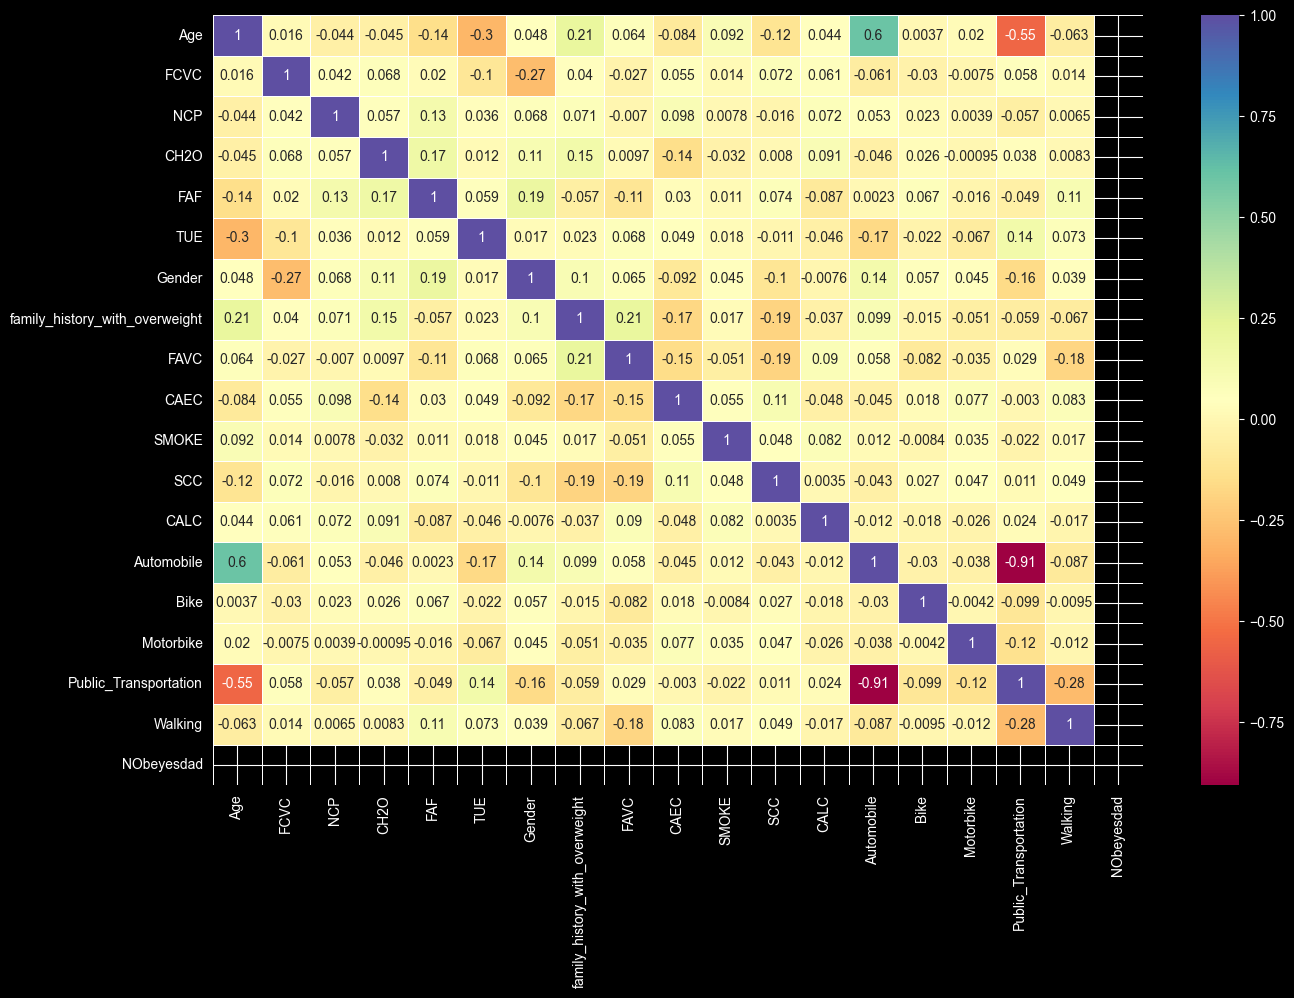

In [143]:
df_categoric=pd.DataFrame(df,columns=categoric_var)
df_new = pd.concat([df_scaled, df_categoric], axis = 1)
plt.figure(figsize=(15,10))
sns.heatmap(data=df_new.corr(),cmap="Spectral",annot=True,linewidth=0.5)
plt.show()